In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
import os
import sys

sys.path.append(os.path.abspath("../../repos/RiskLabAI.py"))
from src.quantum_hrp import compute_financial_features, fetch_stock_data, average_density_matrix, compute_distance_matrix, quantum_ordering, classical_hrp_ordering, simulate_asset_features_regimes



In [2]:
returns = pd.read_csv("../../data/returns.csv", index_col=0, parse_dates=True)
features = np.load("../../data/features.npy")

# checks básicos
print(returns.shape)   # (T, N)
print(features.shape)  # (N, T, P)


(616, 169)
(169, 616, 6)


In [3]:
R = returns.values
corr = np.corrcoef(R, rowvar=False)

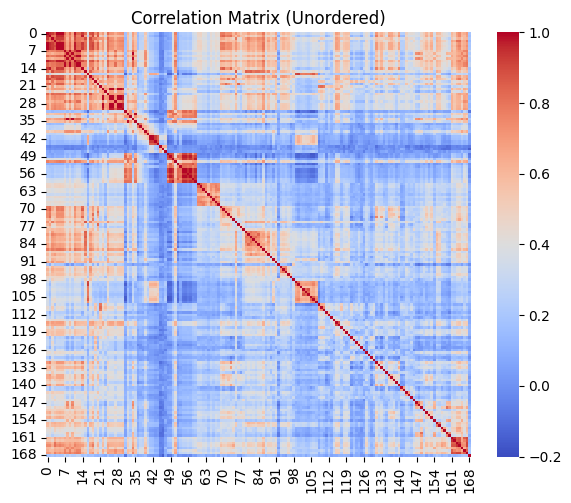

In [4]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    corr,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True
)

plt.title("Correlation Matrix (Unordered)")
plt.tight_layout()
plt.show()

In [5]:
alpha = 2.0
rho_list = []

for i in range(features.shape[0]):
    rho_i = average_density_matrix(features[i], alpha)
    rho_list.append(rho_i)

D_quantum = compute_distance_matrix(rho_list)

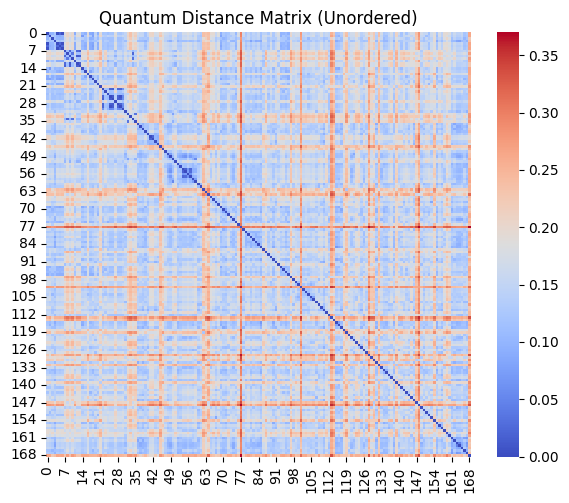

In [6]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    D_quantum,
    cmap="coolwarm",
    square=True,
    cbar=True
)
plt.title("Quantum Distance Matrix (Unordered)")
plt.tight_layout()
plt.show()

In [8]:
# Correlation → distance
dist_classical = np.sqrt(0.5 * (1 - corr))

# Numerical hygiene (CRÍTICO)
dist_classical = 0.5 * (dist_classical + dist_classical.T)
np.fill_diagonal(dist_classical, 0.0)
dist_classical = np.nan_to_num(dist_classical)

# Hierarchical clustering
link_classical = linkage(squareform(dist_classical), method="single")
order_classical = leaves_list(link_classical)


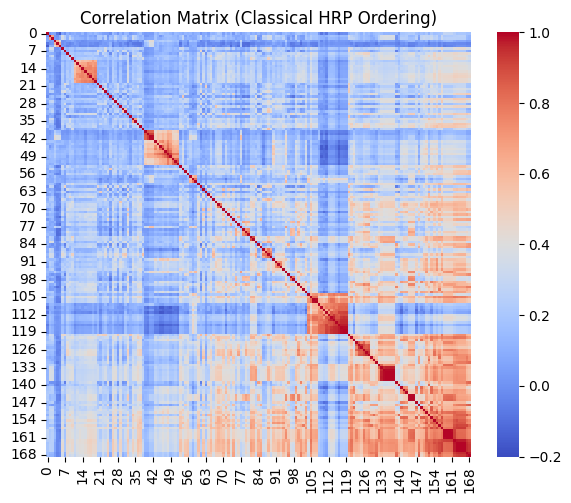

In [9]:
corr_classical = corr[np.ix_(order_classical, order_classical)]

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_classical,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True
)

plt.title("Correlation Matrix (Classical HRP Ordering)")
plt.tight_layout()
plt.show()

In [10]:
link_quantum = linkage(squareform(D_quantum), method="single")
order_quantum = leaves_list(link_quantum)

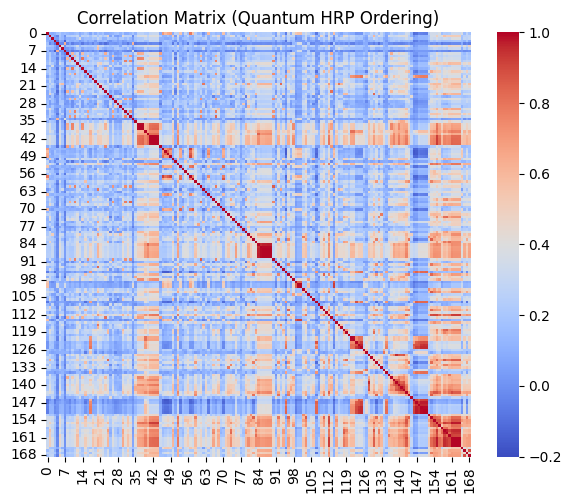

In [11]:
corr_quantum = corr[np.ix_(order_quantum, order_quantum)]

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_quantum,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True
)

plt.title("Correlation Matrix (Quantum HRP Ordering)")
plt.tight_layout()
plt.show()

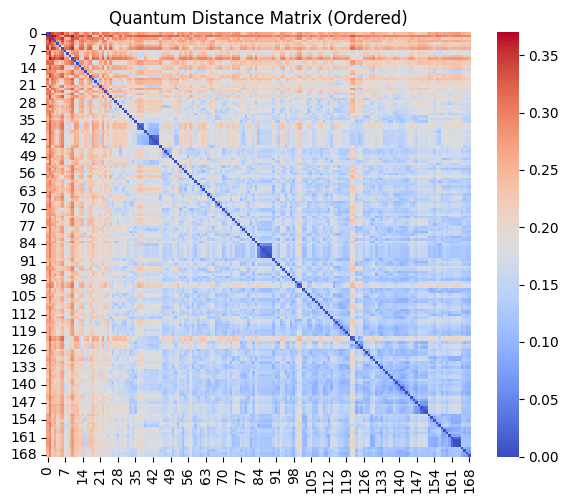

In [12]:
D_quantum_ord = D_quantum[np.ix_(order_quantum, order_quantum)]

plt.figure(figsize=(6, 5))
sns.heatmap(
    D_quantum_ord,
    cmap="coolwarm",
    square=True,
    cbar=True
)
plt.title("Quantum Distance Matrix (Ordered)")
plt.tight_layout()
plt.show()

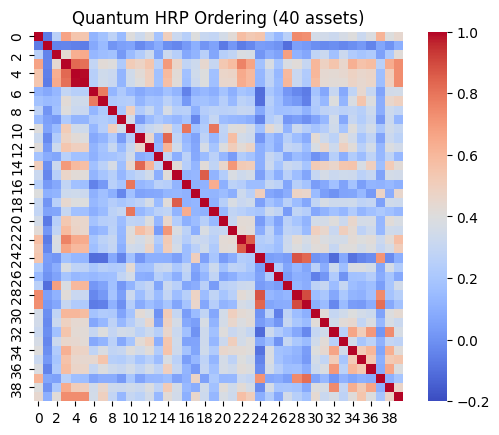

In [13]:
idx = np.random.choice(len(corr), size=40, replace=False)
corr_small = corr[np.ix_(idx, idx)]
D_small = D_quantum[np.ix_(idx, idx)]
order_small = quantum_ordering(D_small)
sns.heatmap(
    corr_small[np.ix_(order_small, order_small)],
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True
)
plt.title("Quantum HRP Ordering (40 assets)")
plt.show()

